In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fake-and-real-news-dataset/True.csv
/kaggle/input/fake-and-real-news-dataset/Fake.csv


# Data Understanding

In [2]:
!pip -q install ydata-profiling langdetect simhash --upgrade --no-input
#ydata-profiling pour le rapport html 
#simhash estimation rapide des near-duplicates.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done


In [3]:
import os, re, warnings, hashlib, unicodedata
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Profiling
try:
    from ydata_profiling import ProfileReport
    HAS_PROFILING = True
except Exception:
    HAS_PROFILING = False

# Langue
try:
    from langdetect import detect, LangDetectException
except Exception:
    detect, LangDetectException = None, Exception

# Fix encodage (fallback si non installé)
try:
    from ftfy import fix_text
except Exception:
    def fix_text(x): return x

# SimHash (quasi-duplicats rapides)
from simhash import Simhash
# Sklearn ( pour splits/modèles)
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Esthétique & options
RNG = 42
plt.rcParams["figure.figsize"] = (6, 4)
pd.set_option("display.max_colwidth", 180)


import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re

In [4]:
DATA_DIR = "/kaggle/input/fake-and-real-news-dataset"

# Lecture 
fake = pd.read_csv(os.path.join(DATA_DIR, "Fake.csv"))
true = pd.read_csv(os.path.join(DATA_DIR, "True.csv"))

# Standardiser noms de colonnes
fake.columns = [c.strip().lower() for c in fake.columns]
true.columns = [c.strip().lower() for c in true.columns]

# Labels 
fake["label"] = 1
true["label"] = 0

df = pd.concat([fake, true], ignore_index=True)
print(df.shape)
display(df.sample(3, random_state=RNG))


(44898, 5)


,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off)...",US_News,"February 13, 2017",1
27917,Trump drops Steve Bannon from National Security Council,"WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decisi...",politicsNews,"April 5, 2017",0
25007,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,"(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restrictions on ships that can p...",politicsNews,"September 27, 2017",0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [6]:
# Statistiques objets (titres, sujets, dates)
df.describe(include='object').transpose()

,count,unique,top,freq
title,44898,38729,Factbox: Trump fills top jobs for his administration,14
text,44898,38646,,627
subject,44898,8,politicsNews,11272
date,44898,2397,"December 20, 2017",182


In [7]:
# Lignes potentiellement dupliquées (juste pour aperçu, pas le nettoyage)
df[df.duplicated(keep=False)]

,title,text,subject,date,label
9941,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS! 2014 VIDEO Of Hillary EMERGES Saying Illegal Kids Should Be Sent Back,"No time to waste we've got to fight with everything we've got to #DefendDACA. Thanks, @jorgeramosnews, for sharing these powerful stories. https://t.co/rNtZZ4ONBy Hillary Cl...",politics,"Sep 9, 2017",1
9942,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS! 2014 VIDEO Of Hillary EMERGES Saying Illegal Kids Should Be Sent Back,"No time to waste we've got to fight with everything we've got to #DefendDACA. Thanks, @jorgeramosnews, for sharing these powerful stories. https://t.co/rNtZZ4ONBy Hillary Cl...",politics,"Sep 9, 2017",1
11445,FORMER DEMOCRAT WARNS Young Americans: “Rioters are being manipulated by big government forces who need them to regain political power” [VIDEO],"Who is silencing political speech, physically attacking those with divergent views, demanding that every American share one single ideology. But sadly, the real truth is that...",politics,"Mar 10, 2017",1
11446,FORMER DEMOCRAT WARNS Young Americans: “Rioters are being manipulated by big government forces who need them to regain political power” [VIDEO],"Who is silencing political speech, physically attacking those with divergent views, demanding that every American share one single ideology. But sadly, the real truth is that...",politics,"Mar 10, 2017",1
14924,"[VIDEO] #BlackLivesMatter Terrorists Storm Dartmouth Library, Threaten Students: ‘F*ck You, You Filthy White F*cks!’","They were probably just looking for a safe space to study Protesters at Dartmouth University disrupted students studying in the library, reportedly directing profanity toward...",politics,"Nov 16, 2015",1
...,...,...,...,...,...
44771,"Europeans, Africans agree renewed push to tackle migrant crisis",PARIS (Reuters) - Europe s big four continental powers and three African states agreed a plan on Monday to tackle illegal human trafficking and support nations struggling to ...,worldnews,"August 28, 2017",0
44826,Thailand's ousted PM Yingluck has fled abroad: sources,BANGKOK (Reuters) - Ousted Thai prime minister Yingluck Shinawatra has fled the country ahead of a verdict against her in a negligence trial brought by the junta that overthrew...,worldnews,"August 25, 2017",0
44834,Thailand's ousted PM Yingluck has fled abroad: sources,BANGKOK (Reuters) - Ousted Thai prime minister Yingluck Shinawatra has fled the country ahead of a verdict against her in a negligence trial brought by the junta that overthrew...,worldnews,"August 25, 2017",0
44887,"U.S., North Korea clash at U.N. forum over nuclear weapons","GENEVA (Reuters) - North Korea and the United States clashed at a U.N. forum on Tuesday over their military intentions towards one another, with Pyongyang s envoy declaring it ...",worldnews,"August 22, 2017",0


In [8]:
# Distribution brute des labels
df.label.value_counts()

label
1    23481
0    21417
Name: count, dtype: int64

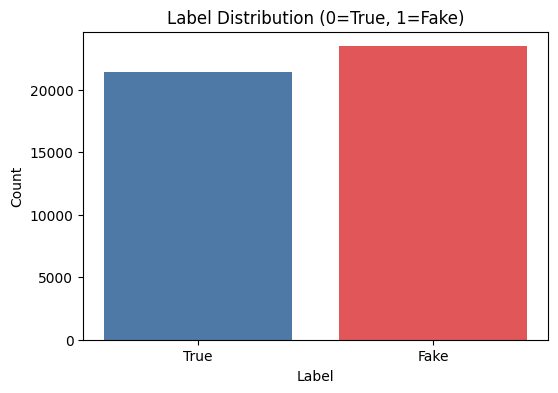

In [9]:
# Visualisation : Distribution label (0=True, 1=Fake)
order = [0, 1]
names = ["True", "Fake"]

counts = df["label"].value_counts().reindex(order, fill_value=0).values

plt.bar(order, counts, color=["#4E79A7", "#E15759"], tick_label=names)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution (0=True, 1=Fake)")
plt.show()

In [10]:
# Sujets 
df.subject.value_counts()


subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

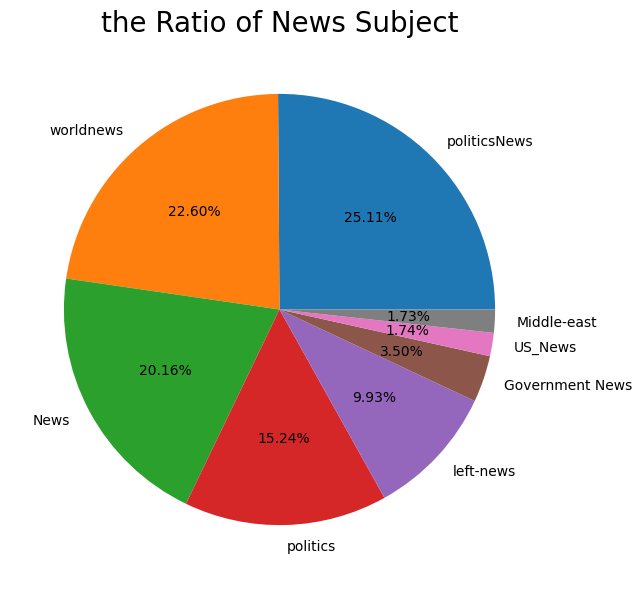

In [11]:
# Wordcloud (avant stopwords — juste indicative)
plt.figure(figsize=(7,7))
plt.pie(x = df['subject'].value_counts() ,autopct='%1.2f%%' ,labels=df['subject'].value_counts().index)
plt.title('the Ratio of News Subject',fontsize=20)
plt.show()

In [12]:
counts = df.groupby(['subject', 'label']).size().unstack(fill_value=1)
counts

label,0,1
subject,,
Government News,1,1570
Middle-east,1,778
News,1,9050
US_News,1,783
left-news,1,4459
politics,1,6841
politicsNews,11272,1
worldnews,10145,1


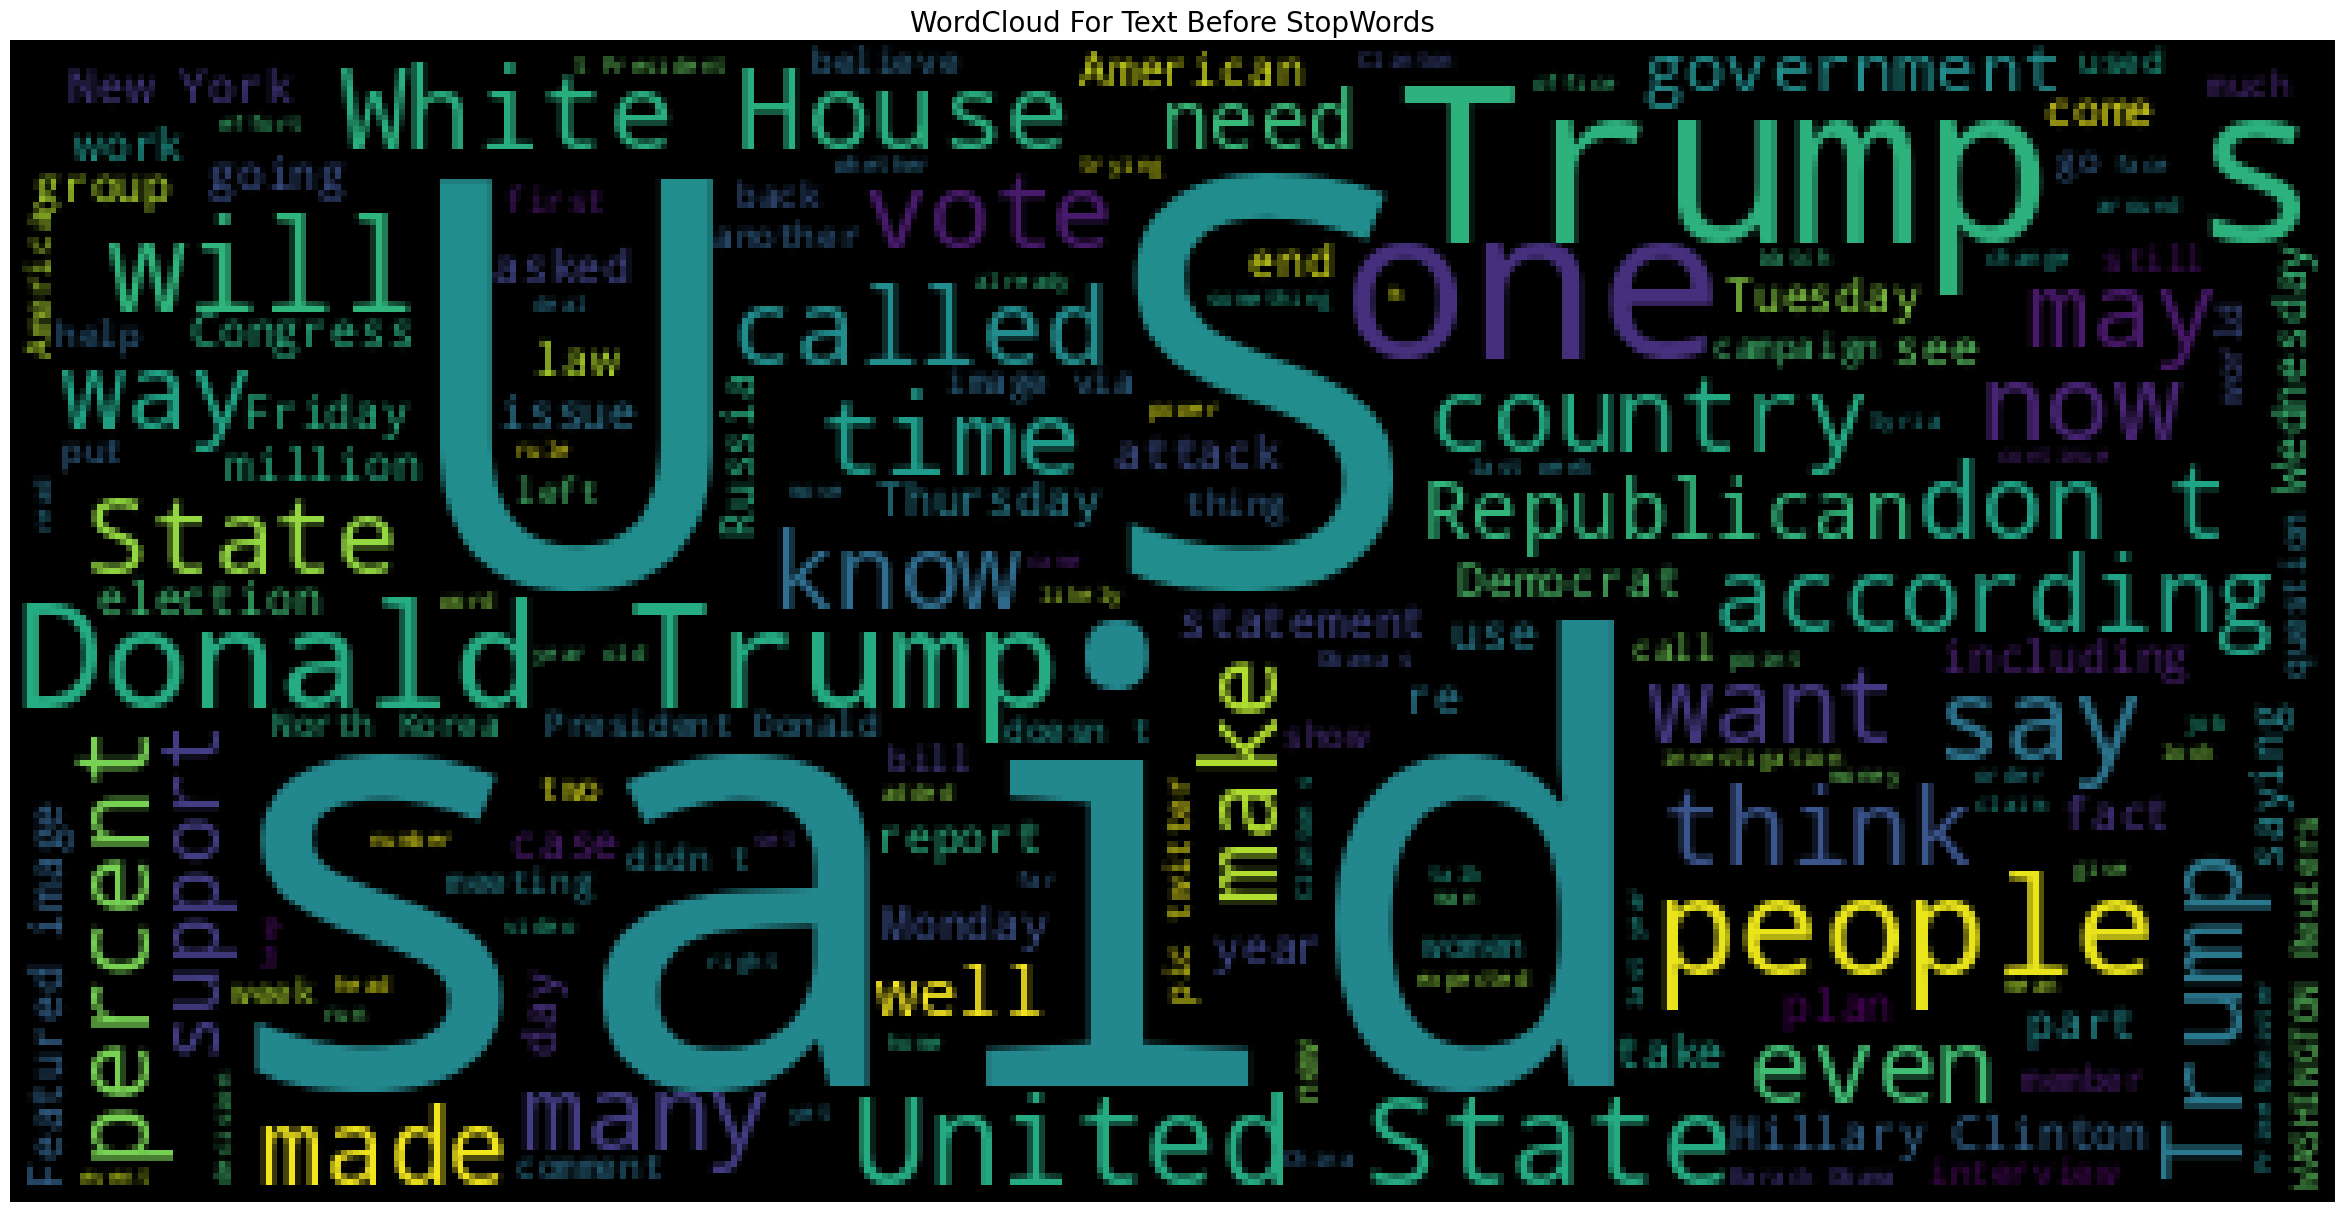

In [13]:
# Wordcloud (avant stopwords — juste indicative)
plt.figure(figsize=(30,20))
plt.imshow(WordCloud(background_color = 'black').generate(" ".join(df.text)))
plt.axis("off")
plt.title("WordCloud For Text Before StopWords",fontsize=20)
plt.show()   

In [14]:
# Profil Exploratory Data Analysis (EDA) 

from ydata_profiling import ProfileReport

profile = ProfileReport(
    df[["title","text","subject","date","label"]].copy(),
    minimal=True, explorative=True
)
profile.to_file("profile.html")
print("Profil EDA généré → profile.html (onglet Files)")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:22<00:00,  4.51s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profil EDA généré → profile.html (onglet Files)


In [15]:
import os, re, warnings, hashlib, unicodedata
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

# Utilitaires dispos (tu les as déjà importés plus haut)
try:
    from ftfy import fix_text
except Exception:
    def fix_text(x): return x

try:
    from langdetect import detect, LangDetectException
except Exception:
    detect, LangDetectException = None, Exception

from simhash import Simhash

RNG = 42
np.random.seed(RNG)

In [16]:
# Vérifs & normalisation colonnes
expected_cols = ["title", "text", "subject", "date", "label"]
assert all(c in df.columns for c in expected_cols), f"Colonnes manquantes: {set(expected_cols)-set(df.columns)}"

# Trim espaces, convertir en str où pertinent
for col in ["title", "text", "subject", "date"]:
    df[col] = df[col].astype(str).str.strip()

In [17]:
# 2) Nettoyage texte de base 
URL_RE = r"(https?://\S+|www\.\S+)"
HANDLE_RE = r"@\w+"
HTML_RE = r"<[^>]+>"
MULTI_WS_RE = r"\s+"

# mots à retirer souvent vus comme boilerplate
BOILERPLATE_PREFIXES = [
    r"^\(?reuters\)?\s*-\s*",      # "(Reuters) - " ou "Reuters - "
    r"^\(?afp\)?\s*-\s*",
]
boilerplate_prefix = re.compile("|".join(BOILERPLATE_PREFIXES), flags=re.IGNORECASE)

def normalize_text(x: str) -> str:
    # fix encodage & accents bizarres
    x = fix_text(x)
    # unicode normalize
    x = unicodedata.normalize("NFKC", x)
    # enlever html
    x = re.sub(HTML_RE, " ", x)
    # urls & handles
    x = re.sub(URL_RE, " ", x)
    x = re.sub(HANDLE_RE, " ", x)
    # emojis/symboles divers -> garder lettres/chiffres ponctuation légère
    x = re.sub(r"[^\w\s\.\,\!\?\:\;\%\-\$\'\"]+", " ", x)
    # retirer boilerplate en début
    x = boilerplate_prefix.sub("", x)
    # espaces
    x = re.sub(MULTI_WS_RE, " ", x).strip()
    # lowercase
    x = x.lower()
    return x

# Appliquer au titre & texte
df["title_clean"] = df["title"].map(normalize_text)
df["text_clean"]  = df["text"].map(normalize_text)

#  si tu veux une version ultra-sobre pour bag-of-words:
def strip_to_words(x: str) -> str:
    x = re.sub(r"[^a-zA-Z\s]", " ", x)
    x = re.sub(MULTI_WS_RE, " ", x).strip().lower()
    return x

df["title_alpha"] = df["title_clean"].map(strip_to_words)
df["text_alpha"]  = df["text_clean"].map(strip_to_words)

print("Exemple après nettoyage:")
display(df[["title", "title_clean"]].head(2))
display(df.loc[:, ["text"]].head(1))


Exemple après nettoyage:


,title,title_clean
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,donald trump sends out embarrassing new year s eve message; this is disturbing
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,drunk bragging trump staffer started russian collusion investigation


,text
0,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake new..."


In [18]:
#3) Vides & lignes trop courtes ---
before = len(df)
mask_text_empty = df["text_clean"].str.len() < 10  # seuil minimal (ajuste si tu veux)
print(f"Lignes avec texte < 10 char: {mask_text_empty.sum()} / {before}")
df = df.loc[~mask_text_empty].copy()


Lignes avec texte < 10 char: 738 / 44898


In [19]:
# 4) Déduplication EXACTE (MD5) + contradictions (info)
def md5_pair(title_clean, text_clean):
    s = (title_clean + " || " + text_clean).encode("utf-8", "ignore")
    return hashlib.md5(s).hexdigest()

df["md5"] = [md5_pair(t, x) for t, x in zip(df["title_clean"], df["text_clean"])]

# Contradictions (mêmes contenus, labels différents)
dup_stats = df.groupby("md5")["label"].nunique()
n_contra = int((dup_stats > 1).sum())
print(f"⚠️ Contradictions de label (mêmes contenus): {n_contra}")

# Drop doublons exacts (garder 1er)
dup_exact_mask = df["md5"].duplicated(keep="first")
print(f"Doublons exacts retirés: {int(dup_exact_mask.sum())}")
df = df.loc[~dup_exact_mask].reset_index(drop=True)

⚠️ Contradictions de label (mêmes contenus): 0
Doublons exacts retirés: 5838


In [20]:
#5) Quasi-doublons (SimHash) — Hamming ≤ 3
def simhash_val(row):
    toks = re.findall(r"\w+", (row["title_alpha"] + " " + row["text_alpha"]))
    shingles = [" ".join(toks[i:i+3]) for i in range(len(toks)-2)] or toks
    return Simhash(shingles).value

df["simhash"] = df.apply(simhash_val, axis=1)
df["bucket"]  = df["simhash"].apply(lambda v: v >> (64 - 16))  # 16 bits de tête

def hamming(a, b): return (a ^ b).bit_count()

keep = np.ones(len(df), dtype=bool)
for b, grp in df.sort_values("bucket").groupby("bucket"):
    sims = grp["simhash"].values
    idxs = grp.index.values
    kept_local = []
    for i, idx_i in enumerate(idxs):
        if any(hamming(sims[i], sims[j]) <= 3 for j in kept_local):
            keep[idx_i] = False
        else:
            kept_local.append(i)

n_near = int((~keep).sum())
df = df.loc[keep].reset_index(drop=True)
df.drop(columns=["bucket"], inplace=True)
print(f"Quasi-doublons retirés (dist≤3): {n_near} | total={len(df)}")

# group_id pour splits sans fuite (recalcule propre)
df["group_id"] = [md5_pair(t, x) for t, x in zip(df["title_clean"], df["text_clean"])]


Quasi-doublons retirés (dist≤3): 25 | total=38297


In [21]:
# 6) Détection de langue
if detect is not None:
    def is_en(s):
        try: return detect(s) == "en"
        except LangDetectException: return False
    # estimation échantillon
    p_en = df["text_clean"].sample(min(3000, len(df)), random_state=RNG).map(is_en).mean()
    print(f"🌐 Estimation % anglais (échantillon): {100*p_en:.1f}%")
    df["is_en"] = df["text_clean"].map(is_en)
    removed = int((~df["is_en"]).sum())
    df = df.loc[df["is_en"]].drop(columns=["is_en"]).reset_index(drop=True)
    print(f"Non-EN retirés: {removed} | total={len(df)}")
else:
    print("LangDetect indisponible — pas de filtre langue.")



🌐 Estimation % anglais (échantillon): 99.9%
Non-EN retirés: 13 | total=38284


In [22]:
#  7) Dates: parsing + features calendrier 
def parse_date_safe(x: str):
    for fmt in ("%B %d, %Y", "%b %d, %Y"):
        try: return pd.to_datetime(x, format=fmt)
        except Exception: pass
    return pd.to_datetime(x, errors="coerce")

df["date_dt"] = df["date"].map(parse_date_safe)
n_bad = int(df["date_dt"].isna().sum())
print("Dates non parsées:", n_bad)
if n_bad > 0:
    df.loc[df["date_dt"].isna(), "date_dt"] = df["date_dt"].median()

df["year"]  = df["date_dt"].dt.year.astype(int)
df["month"] = df["date_dt"].dt.month.astype(int)
df["dow"]   = df["date_dt"].dt.dayofweek.astype(int)

Dates non parsées: 1


In [23]:
#  8) Normaliser subject + feature texte finale
df["subject"] = (df["subject"].str.strip()
                               .str.replace("_","-", regex=False)
                               .str.replace(" ","-", regex=False)
                               .str.replace(r"[-]{2,}","-", regex=True)
                               .str.lower())
SUBJ_MAP = {"politicsnews":"politics-news","worldnews":"world-news","us_news":"us-news"}
df["subject"] = df["subject"].map(lambda s: SUBJ_MAP.get(s, s))


In [24]:
#  9) Feature texte finale 
df["text_full"] = (df["title_clean"].fillna("") + " . " + df["text_clean"].fillna("")).str.strip()


In [25]:
# --- Split group-aware 80/10/10 + exports ---
import numpy as np, os, json, hashlib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

# group_id stable basé sur le contenu nettoyé
df["group_id"] = (df["title_clean"] + " || " + df["text_clean"]).map(
    lambda x: hashlib.md5(x.encode("utf-8","ignore")).hexdigest()
)

X_idx  = np.arange(len(df))
y      = df["label"].values
groups = df["group_id"].values

# 80 / 20
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(X_idx, y, groups=groups))

# 10 / 10 (remap des indices relatifs → globaux)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_rel, test_rel = next(gss2.split(X_idx[temp_idx], y[temp_idx], groups=groups[temp_idx]))
val_idx  = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

# sanity checks sur indices GLOBAUX
S_tr, S_va, S_te = set(train_idx), set(val_idx), set(test_idx)
assert S_tr.isdisjoint(S_va) and S_tr.isdisjoint(S_te) and S_va.isdisjoint(S_te)
for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    labs = set(df.loc[idx, "label"].unique().tolist())
    assert labs == {0,1}, f"{name}: classes manquantes {labs}"
print("✅ Splits OK.")

# build DFs
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

def dist(name, d):
    vc = d["label"].value_counts(normalize=True).sort_index()
    return f"{name}: n={len(d)} | p(True=0)={vc.get(0,0):.3f} | p(Fake=1)={vc.get(1,0):.3f}"
print(dist("train", train_df))
print(dist("val",   val_df))
print(dist("test",  test_df))

# exports
os.makedirs("processed", exist_ok=True)
cols_keep = ["title","text","subject","date_dt","label","text_full","year","month","dow"]
train_df[cols_keep].to_csv("processed/train.csv", index=False)
val_df[cols_keep].to_csv("processed/val.csv", index=False)
test_df[cols_keep].to_csv("processed/test.csv", index=False)

cls_w = compute_class_weight("balanced", classes=np.array([0,1]), y=train_df["label"].values)
class_weights = {0: float(cls_w[0]), 1: float(cls_w[1])}
with open("processed/class_weights.json","w") as f: json.dump(class_weights, f, indent=2)

print("💾 Écrit dans ./processed  |  class_weights:", class_weights)


✅ Splits OK.
train: n=30627 | p(True=0)=0.547 | p(Fake=1)=0.453
val: n=3828 | p(True=0)=0.536 | p(Fake=1)=0.464
test: n=3829 | p(True=0)=0.551 | p(Fake=1)=0.449
💾 Écrit dans ./processed  |  class_weights: {0: 0.9141842278072951, 1: 1.1035961372153358}


In [26]:
# --- Imports de base ---
import os, json, numpy as np, pandas as pd, torch
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, brier_score_loss)
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, EarlyStoppingCallback)

# --- Patch anti "additional_chat_templates" (neutralise l'appel 404) ---
from transformers.utils import hub as _hub_mod
from transformers import tokenization_utils_base as _tub_mod
def _no_templates(*a, **k): return []
_hub_mod.list_repo_templates = _tub_mod.list_repo_templates = _no_templates
print("Patched list_repo_templates → OK")

# --- Device & seeds ---
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# --- Chargement modèle + tokenizer avec fallbacks ---
from transformers import AutoTokenizer, AutoModelForSequenceClassification

CANDIDATES = [
    "microsoft/deberta-v3-base",  # cible
    "roberta-base",               # fallback 1
    "distilbert-base-uncased",    # fallback 2 (léger et sûr)
]

tokenizer = model = model_id = None
last_err = None
for mid in CANDIDATES:
    try:
        print("Trying:", mid)
        tok = AutoTokenizer.from_pretrained(mid, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(mid, num_labels=2)
        tokenizer, model, model_id = tok, mdl, mid
        break
    except Exception as e:
        print(" -> failed:", e)
        last_err = e
if model is None:
    raise RuntimeError(f"All candidates failed.\nLast error:\n{last_err}")

model.to(device)
print(f"✅ Loaded model: {model_id} on {device}")


2025-10-16 00:41:34.021957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760575294.297649      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760575294.370778      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Patched list_repo_templates → OK
Device: cuda
Trying: microsoft/deberta-v3-base


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Loaded model: roberta-base on cuda


In [27]:
train_df = pd.read_csv("processed/train.csv")
val_df   = pd.read_csv("processed/val.csv")
test_df  = pd.read_csv("processed/test.csv")
print("Shapes:", train_df.shape, val_df.shape, test_df.shape)


Shapes: (30627, 9) (3828, 9) (3829, 9)


In [28]:
MAX_LEN = 256  # (tu pourras tester 512 en ablation)

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels.astype(int).values
        self.tok = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        enc = self.tok(str(self.texts.iloc[i]),
                       truncation=True, padding="max_length",
                       max_length=self.max_len, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

ds_train = NewsDataset(train_df["text_full"], train_df["label"], tokenizer, MAX_LEN)
ds_val   = NewsDataset(val_df["text_full"],   val_df["label"],   tokenizer, MAX_LEN)
ds_test  = NewsDataset(test_df["text_full"],  test_df["label"],  tokenizer, MAX_LEN)

# Poids de classes (déséquilibre)
cls_w = compute_class_weight("balanced", classes=np.array([0,1]), y=train_df["label"].values)
w = torch.tensor(cls_w, dtype=torch.float32).to(device)
print("Class weights:", {0: float(cls_w[0]), 1: float(cls_w[1])})


Class weights: {0: 0.9141842278072951, 1: 1.1035961372153358}


In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = probs.argmax(axis=1)
    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    try: auc = roc_auc_score(labels, probs[:,1])
    except: auc = float("nan")
    return {"accuracy": acc, "f1_macro": f1m, "auroc": auc}

def custom_loss(model, inputs, return_outputs=False):
    labels = inputs.pop("labels")
    out = model(**inputs)
    loss = torch.nn.CrossEntropyLoss(weight=w)(out.logits, labels)
    return (loss, out) if return_outputs else loss
